In [ ]:
import pandas as pd
import matplotlib as plt
import numpy as np

from nPest.np import ecdf, kde

df = pd.read_csv('./nPest/heart_failure_clinical_records_dataset.csv')
x = df['age']

FileNotFoundError: [Errno 2] No such file or directory: './data/heart_failure_clinical_records_dataset.csv'

## Make an ECDF

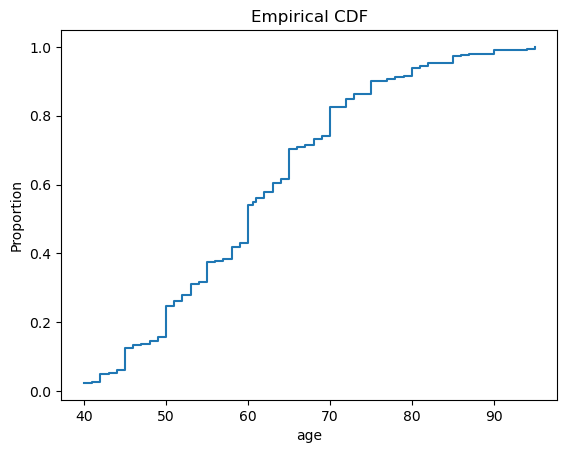

In [2]:
model = ecdf(x)
model.plot()

## Compute Sample Proportion/ECDF Value from Fitted ECDF

In [3]:
model.prop(56)

np.float64(0.3779264214046823)

## Compute Quantile from Fitted ECDF

In [4]:
model.quantile(.7)

np.float64(65.0)

## Make a KDE

Bandwidth is: 6.99


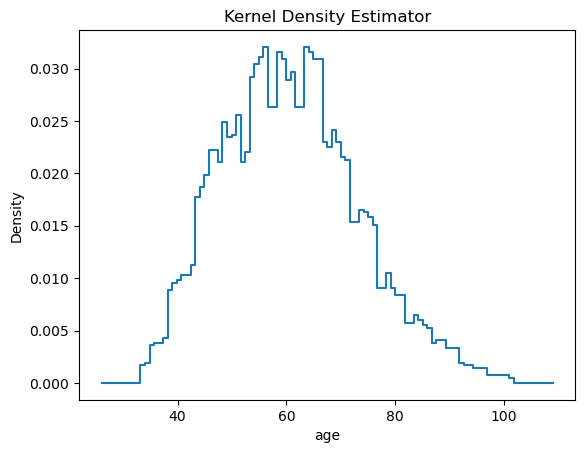

In [5]:
model = kde(x, kernel_type='uniform')
model.fit()
model.plot()
print( f'Bandwidth is: {model.h:.2f}' )

Bandwidth is: 4.03


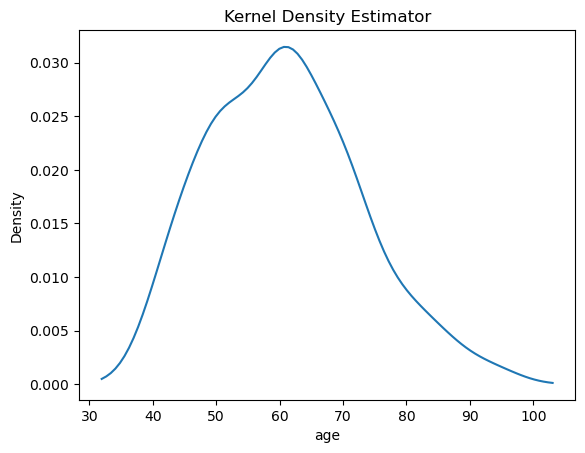

In [6]:
model = kde(x, kernel_type='gaussian')
model.fit()
model.plot()
print( f'Bandwidth is: {model.h:.2f}' )

## Overlay Plots in a Loop

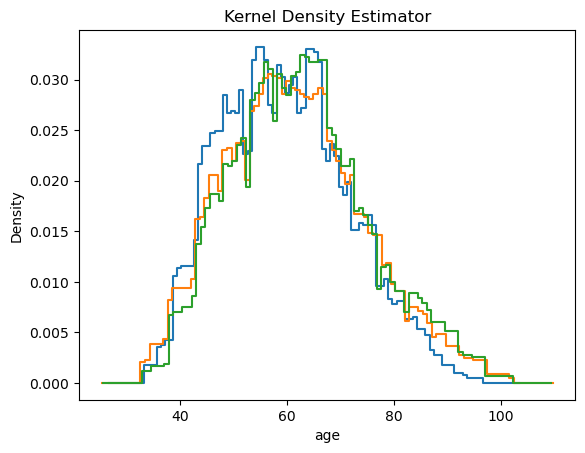

In [7]:
for i in range(3):
    df_i = df.sample( frac = 1.0, replace = True )
    model = kde( df_i['age'])
    model.fit()
    model.plot()

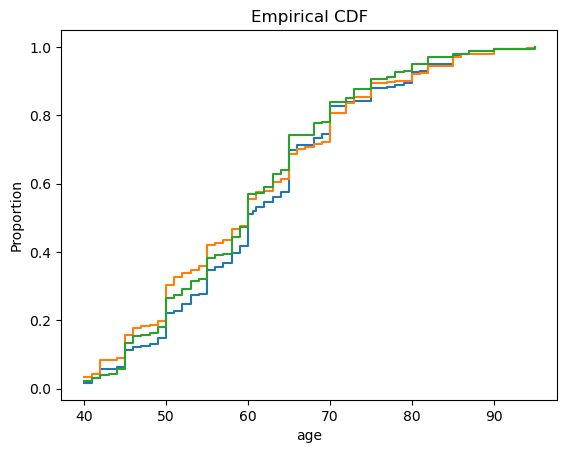

In [8]:
for i in range(3):
    df_i = df.sample( frac = 1.0, replace = True )
    model = ecdf( df_i['age'])
    model.plot()

## Vary the Bandwidth

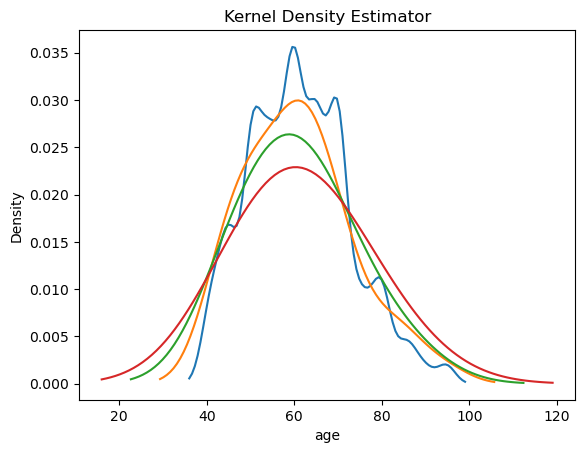

In [9]:
h_grid = np.linspace(2,12,4)

for h in h_grid:
    df_i = df.sample( frac = 1.0, replace = True )
    model = kde( df_i['age'], kernel_type='gaussian' )
    model.fit(h=h)
    model.plot()

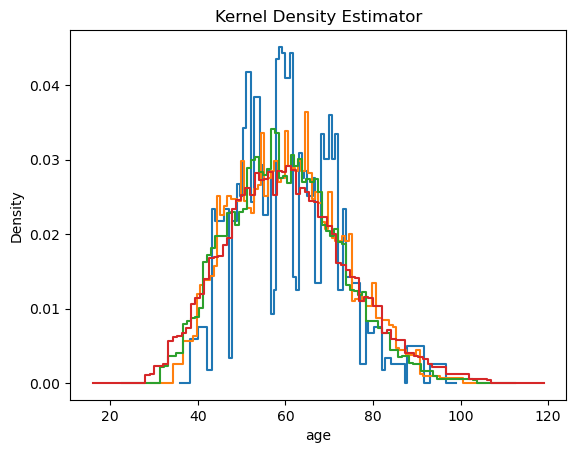

In [10]:
h_grid = np.linspace(2, 12, 4)

for h in h_grid:
    df_i = df.sample( frac = 1.0, replace = True )
    model = kde( df_i['age'], kernel_type='uniform' )
    model.fit(h=h)
    model.plot()

## Vary the Kernel

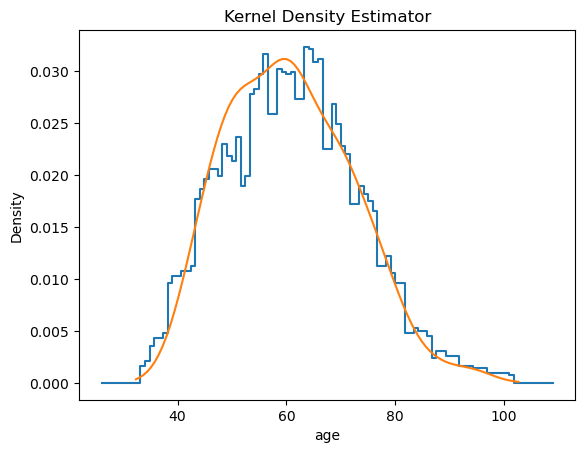

In [11]:
h_grid = np.linspace(2,12,10)

for type in ['uniform', 'gaussian']:
    df_i = df.sample( frac = 1.0, replace = True )
    model = kde( df_i['age'], kernel_type= type)
    model.fit()
    model.plot()